## Triggered speed

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums

In [3]:
from position_tools import (
    get_angle,
    get_distance,
    get_speed,
    get_velocity,
    interpolate_nan,
)

In [7]:
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new
from spyglass.shijiegu.changeOfMind_triggered_position import return_triggered_2d_position

In [8]:
### use what we parsed in figure 3b

In [9]:
list_of_days_animals = {}
success_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']

In [ ]:
decoder_type = "run_time"
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4'
animal = "julio"

days = list_of_days_animals[animal]
file_path = f"{output_folder}/prepost_{decoder_type}_{animal}_{False}.pickle"
with open(file_path, 'rb') as file:
    loaded_data_all_days = pickle.load(file)
    print(f"Data successfully loaded from {file_path}")
    
    position_pre, position_post = [], []
    time_pre, time_post = [], []
    se
    
    for day in days:
        
        load_data = loaded_data_all_days[day]
        position_pre.extend(load_data["pos_pre"])
        position_post.extend(load_data["pos_post"])
        time_pre.extend(load_data["time_pre"])
        time_post.extend(load_data["time_post"])
        "session_info_pre":session_info_pre

    for ind in range(len())

In [28]:
loaded_data_all_days.keys()

dict_keys(['20230731', '20230801', '20230802', '20230803', '20230804', '20230805', '20230806', '20230807', '20230808', '20230809', '20230810', '20230811'])

In [29]:
load_data = loaded_data_all_days['20230731']

In [10]:
from spyglass.shijiegu.changeOfMind_figures.figure4c import get_position_decode_data_day, load_day_position_info
from spyglass.shijiegu.helpers import intersection_of_lists

In [11]:
animal = "julio"
day = "20230808"
data = get_position_decode_data_day(animal, day, "run", hpd_flag = False, do_control = False)

[2026-02-04 17:22:05,670][WARNING]: Skipped checksum for file with hash: 7e226eb3-bfbf-fc49-6ea3-f4b3f85099cd, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_4AGPFHP97D.nwb
[2026-02-04 17:22:05,678][WARNING]: Skipped checksum for file with hash: 7e226eb3-bfbf-fc49-6ea3-f4b3f85099cd, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_4AGPFHP97D.nwb
[2026-02-04 17:22:05,684][WARNING]: Skipped checksum for file with hash: 7e226eb3-bfbf-fc49-6ea3-f4b3f85099cd, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_4AGPFHP97D.nwb
[2026-02-04 17:22:05,689][WARNING]: Skipped checksum for file with hash: 7e226eb3-bfbf-fc49-6ea3-f4b3f85099cd, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_4AGPFHP97D.nwb
[2026-02-04 17:22:15,621][WARNING]: Skipped checksum for file with hash: 37098ac7-e1e1-a0ef-9f72-8d15c56d02bf, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_FEUCU1G9X6.nwb
[2026-02-04 17:22:15,633][WARNING]: Skipped checksum for file with hash: 37

In [12]:
data.keys()

dict_keys(['pos_pre', 'decode_pre', 'time_pre', 'session_info_pre', 'pos_post', 'decode_post', 'time_post', 'session_info_post', 'speed_pre', 'speed_post'])

In [18]:
len(data['speed_pre'][-1])

1001

In [ ]:

# (1) get speed 
# (2) find initial time
# (3) restrict to -2s to 2s
# (4) find duration of speed less than 4cm/s
# (5) add pre and post together for each trial

pos, timestamps = data["pos_pre"],data['time_pre']

for ind in range(len(pos)):
    

In [84]:
len(data["session_info_post"])

8

In [2]:
def figure_speed_data(animal, day, encoding_set, classifier_param_name):
    parameters = {"proportion": 0.1,
                  "delta_t_minus":5, "delta_t_plus":5,
                  "max_flag":0, "segment_only": False,
                  "control": False}
    
    
    loaded_data = load_triggered_position_decode_day_spyglass(animal, day, encoding_set, classifier_param_name, **parameters)
    positions = loaded_data["triggered_positions"]
    positions_abs = loaded_data["triggered_positions_baseoff"]
    trial_infos = loaded_data["triggered_trial_info"]
    positions_2D = return_triggered_2d_position(positions_abs, trial_infos)
    
    # # control day
    # parameters["control"] = True
    # loaded_data_control = load_triggered_position_decode_day(animal, day, encoding_set, classifier_param_name, **parameters)
    # positions_control = loaded_data_control["triggered_positions"]
    # positions_abs_control = loaded_data_control["triggered_positions_baseoff"]
    # trial_infos_control = loaded_data_control["triggered_trial_info"]
    # positions_2D_control = return_triggered_2d_position(positions_abs_control, trial_infos_control)

    return positions, positions_2D#, positions_control, positions_2D_control
    
def figure_speed_plot(positions, positions_2D, positions_control, positions_2D_control):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3),sharex=False)

    for ind in range(len(positions)):
        time = positions[ind].index
        speed = positions_2D[ind].head_speed

        if len(time)!=len(speed):
            print(f"some sampling problem, removing {ind}")
            continue
        ax1.plot(time, speed, linewidth = 1, alpha = 0.5, color = 'k')
        ax2.plot(time, speed, linewidth = 1, alpha = 0.5, color = 'k')
    
    # control data
    # for ind in range(len(positions_2D_control)):
    #     time = positions_control[ind].index
    #     speed = positions_2D_control[ind].head_speed
    #     if len(time)!=len(speed):
    #         print(f"some sampling problem, removing {ind}")
    #         continue
    #     ax1.plot(time, speed, linewidth = 1, alpha = 0.5, color = 'C1')
    #     ax2.plot(time, speed, linewidth = 1, alpha = 0.5, color = 'C1')
    
    ax1.set_xlim([-0.2,0.2])
    
    
    ax1.set_title(f"{animal}\n{day}\n animal speed")
    ax1.set_xlabel("time (seconds), relative to stopping")
    ax1.set_ylabel("speed (cm/s)")


    ax2.set_xlim([-2,2])
    
    ax1.axhline(4, linewidth = 1, color = 'C0', linestyle = '--')
    ax2.axhline(4, linewidth = 1, color = 'C0', linestyle = '--')

    ax1.set_ylim([-5,90])
    ax2.set_ylim([-5,90])
    
    ax2.set_title(f"{animal}\n{day}\n animal speed")
    ax2.set_xlabel("time (seconds), relative to stopping")
    ax2.set_ylabel("speed (cm/s)")
    
    
    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure2/speed_{animal}_{day}"
    plt.savefig(file_path + ".pdf")
    plt.savefig(file_path + ".png",dpi=300,bbox_inches='tight') 

    return 1

In [3]:
encoding_sets = {}
classifier_param_names = {}
days = {}

# load triggered_position_decode
animal = "Molly"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20220418'

animal = "Eliot"
encoding_sets[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20221021'

animal = "Klein"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20231107'

animal = "Julio"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20230808'

animal = "Lewis"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20240108'

In [105]:
### data making

output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'

for animal in ["Lewis"]:#days.keys():
    day = days[animal]
    encoding_set = encoding_sets[animal]
    classifier_param_name = classifier_param_names[animal]

    data = {}
    data["positions"], data["positions_2D"], data["positions_control"], data["positions_2D_control"] = figure_speed_data(
        animal, day, encoding_set, classifier_param_name)

    file_path = f"{output_folder}/{animal[:5]}_speed.pickle"
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")
    

[2025-10-12 16:34:39,642][WARNING]: Skipped checksum for file with hash: 17fea632-b2df-984d-580d-f0f8fede3b39, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_KIQBPKH7QI.nwb
[2025-10-12 16:34:39,657][WARNING]: Skipped checksum for file with hash: 17fea632-b2df-984d-580d-f0f8fede3b39, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_KIQBPKH7QI.nwb
[2025-10-12 16:34:39,663][WARNING]: Skipped checksum for file with hash: 17fea632-b2df-984d-580d-f0f8fede3b39, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_KIQBPKH7QI.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/lewis_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_p0.1_tm5_tp5_maxflag0_controlFalse_allposterior.pkl':


[2025-10-12 16:34:40,319][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[2025-10-12 16:34:40,328][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[2025-10-12 16:34:40,332][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[2025-10-12 16:34:40,687][WARNING]: Skipped checksum for file with hash: c7ff6094-5a97-d28e-8ca8-5e3b9940a682, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_E5J2EZUBAR.nwb
[2025-10-12 16:34:40,696][WARNING]: Skipped checksum for file with hash: c7ff6094-5a97-d28e-8ca8-5e3b9940a682, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_E5J2EZUBAR.nwb
[2025-10-12 16:34:40,700][WARNING]: Skipped checksum for file with hash: c7

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/lewis_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_p0.1_tm5_tp5_maxflag0_controlTrue_allposterior.pkl':


[2025-10-12 16:34:44,424][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[2025-10-12 16:34:44,433][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[2025-10-12 16:34:44,437][WARNING]: Skipped checksum for file with hash: 12d551fb-a9c1-4baf-8ea2-c0fc6d8552c3, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_2KIVRI0X14.nwb
[2025-10-12 16:34:44,637][WARNING]: Skipped checksum for file with hash: c7ff6094-5a97-d28e-8ca8-5e3b9940a682, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_E5J2EZUBAR.nwb
[2025-10-12 16:34:44,647][WARNING]: Skipped checksum for file with hash: c7ff6094-5a97-d28e-8ca8-5e3b9940a682, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_E5J2EZUBAR.nwb
[2025-10-12 16:34:44,651][WARNING]: Skipped checksum for file with hash: c7

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure2/Lewis_speed.pickle


In [8]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Molly_speed.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Eliot_speed.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Klein_speed.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Lewis_speed.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Julio_speed.pickle


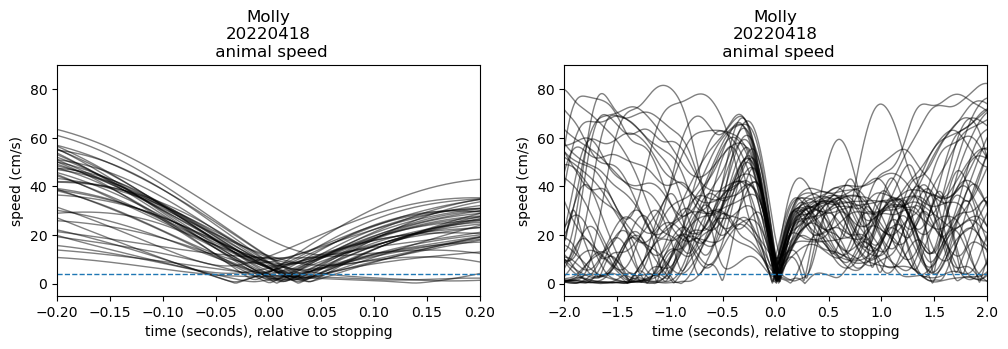

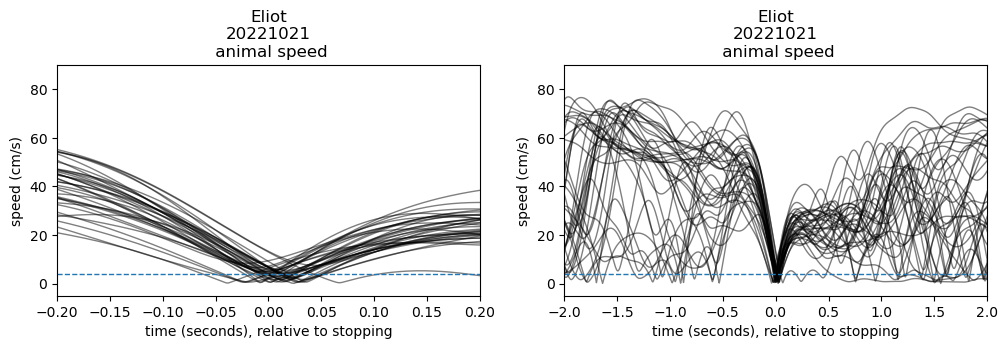

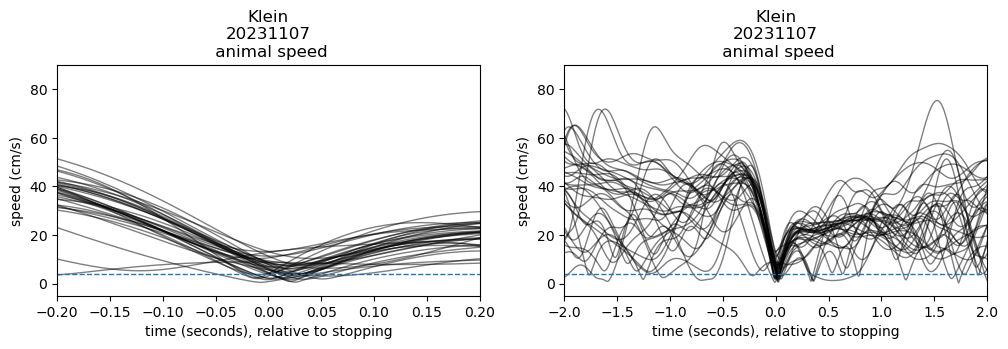

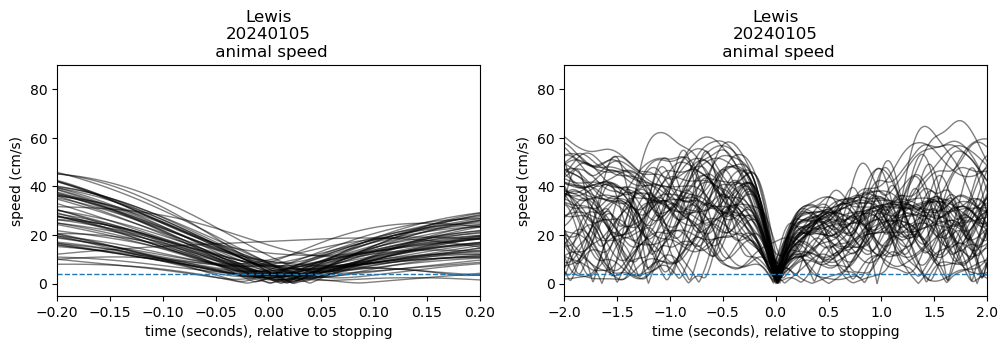

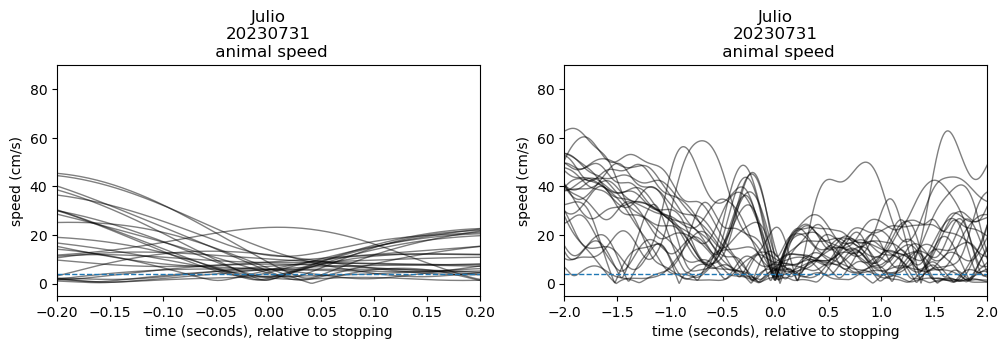

In [9]:
### data plotting
for animal in ["Molly","Eliot","Klein","Lewis","Julio"]:
    day = days[animal]
    encoding_set = encoding_sets[animal]
    classifier_param_name = classifier_param_names[animal]
    
    file_path = f"{output_folder}/{animal}_speed.pickle"
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")
        
    figure_speed_plot(data["positions"], data["positions_2D"], data["positions_control"], data["positions_2D_control"])

### End here

In [52]:
(positions, positions_abs, decodes, decodes_abs) = (triggered_positions[animal], triggered_positions_abs[animal],
     triggered_decodes[animal], triggered_decodes_baseoff[animal])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5),sharex=True)

for position in positions:
    ax1.plot(position, linewidth = 1, alpha = 0.5, color = 'k')

row_ind = 0
for rendition_ind in range(len(positions_abs)):
    position_abs = positions_abs[rendition_ind]
    position = positions[rendition_ind]
    decode_abs = decodes_abs[rendition_ind]
    if len(position_abs) == len(decode_abs):
        ax2.plot(position.index, np.array(decode_abs) - np.array(position_abs), linewidth = 1, alpha = 0.5, color = 'k')
    row_ind = row_ind + 1

ax1.set_title(animal + "\n animal position relative to stopping")
ax2.set_title("decoded position relative to physical location")

ax1.set_ylabel("linearized location (cm)")
ax2.set_xlabel("time (seconds)")
ax2.set_ylabel("linearized location (cm)")

NameError: name 'triggered_positions' is not defined